## Introduction

This project focuses on classifying tweets into categories using Recurrent Neural Network (RNN) architectures. We explore and compare three models: Simple RNN, LSTM with a trainable embedding layer, and LSTM with pretrained Word2Vec (GloVe) embeddings. The goal is to evaluate which architecture performs best on the task of text classification.


In [ ]:
import pandas as pd
import numpy as np
import re
import contractions
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd
import numpy as np
import re
import contractions
import matplotlib.pyplot as plt


from wordcloud import WordCloud

import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

from gensim.models import Word2Vec

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
import tensorflow as tf
print(tf.__version__)

2.17.1


In [ ]:
!pip install seaborn

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Saving news_category.csv to news_category.csv
                                            headline        category
0  How A New Documentary Captures The Complexity ...  CULTURE & ARTS
1  Twitch Bans Gambling Sites After Streamer Scam...            TECH
2  'Reboot' Is A Clever And Not Too Navel-Gazey L...  CULTURE & ARTS
3  Maury Wills, Base-Stealing Shortstop For Dodge...          SPORTS
4  Las Vegas Aces Win First WNBA Title, Chelsea G...          SPORTS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11025 entries, 0 to 11024
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   headline  11025 non-null  object
 1   category  11025 non-null  object
dtypes: object(2)
memory usage: 172.4+ KB
None


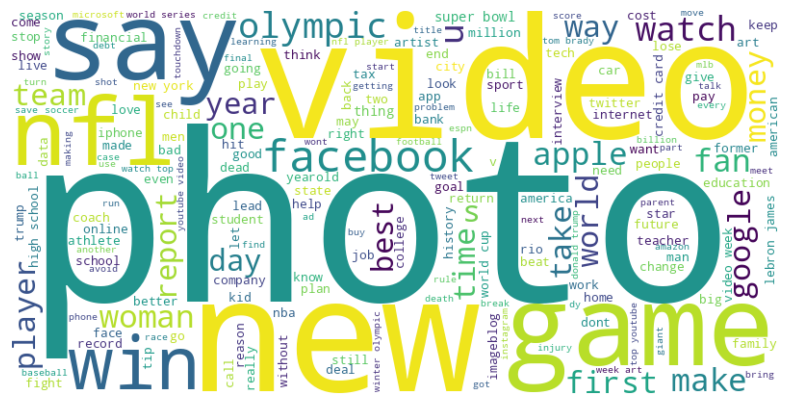

['CULTURE & ARTS' 'EDUCATION' 'MONEY' 'SPORTS' 'TECH']


In [ ]:
# =========================
# 1. INSTALL DEPENDENCIES
# =========================
!pip install -q wordcloud tensorflow nltk seaborn

# =========================
# 2. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk

from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# =========================
# 3. DOWNLOAD NLTK DATA
# =========================
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# =========================
# 4. LOAD DATASET
# =========================
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(next(iter(uploaded)))

# =========================
# 5. BASIC CHECK
# =========================
print(df.head())
print(df.info())

# =========================
# 6. CLEANING FUNCTION
# =========================
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.strip()

    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return " ".join(words)

# =========================
# 7. APPLY CLEANING (FIXED COLUMN)
# =========================
df['clean_text'] = df['headline'].apply(clean_text)

# =========================
# 8. LABEL ENCODING (FIXED COLUMN)
# =========================
label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['category'])

# =========================
# 9. TOKENIZATION
# =========================
max_words = 5000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(df['clean_text'])

X = tokenizer.texts_to_sequences(df['clean_text'])
X = pad_sequences(X, maxlen=max_len)

y = df['label_encoded']

# =========================
# 10. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 11. WORD CLOUD
# =========================
all_words = " ".join(df['clean_text'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

# =========================
# 12. LABEL CHECK (OPTIONAL)
# =========================
print(label_encoder.classes_)

Shape: (11025, 4)
Columns: Index(['headline', 'category', 'clean_text', 'label_encoded'], dtype='object')


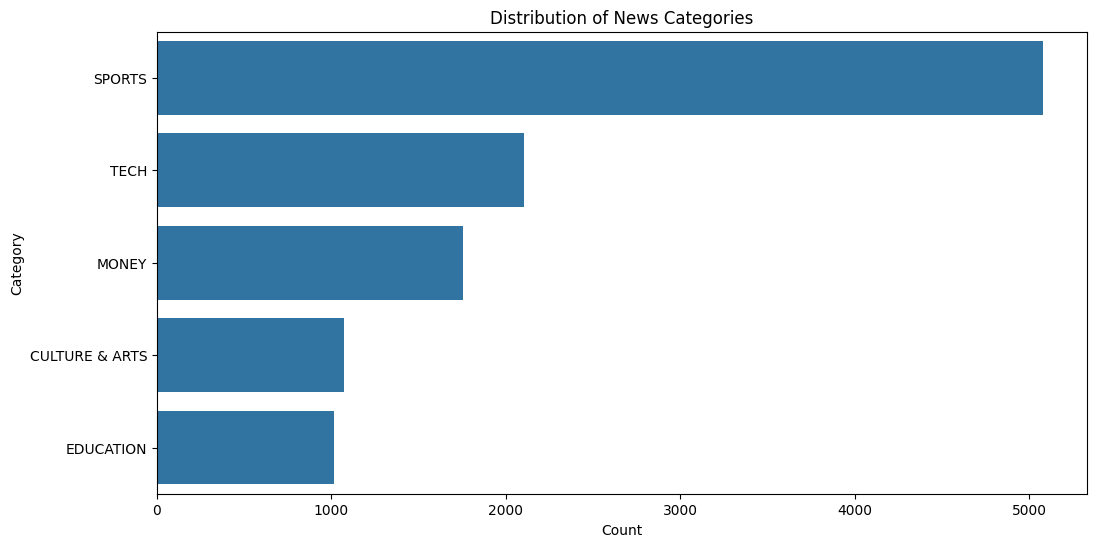

In [ ]:
# Basic check
print("Shape:", df.shape)
print("Columns:", df.columns)
df = df[['headline', 'category']].dropna()

# Dataset visualization: category distribution
plt.figure(figsize=(12,6))
sns.countplot(y=df['category'], order=df['category'].value_counts().index)
plt.title('Distribution of News Categories')
plt.xlabel('Count')
plt.ylabel('Category')
plt.show()


## Text Preprocessing, Tokenization, and Sequence Padding

The raw tweet data was first cleaned using the following steps:
- Converted text to lowercase for consistency.
- Removed URLs, mentions (@), hashtags (#), numbers, and punctuation.
- Handled common contractions (e.g., "don't" → "do not").
- Removed English stopwords and lemmatized words.

Tokenization was performed using Keras's `Tokenizer`, and sequences were padded using the 95th percentile of sequence lengths to avoid excessive padding. Finally, the dataset was split into 80% training and 20% testing.


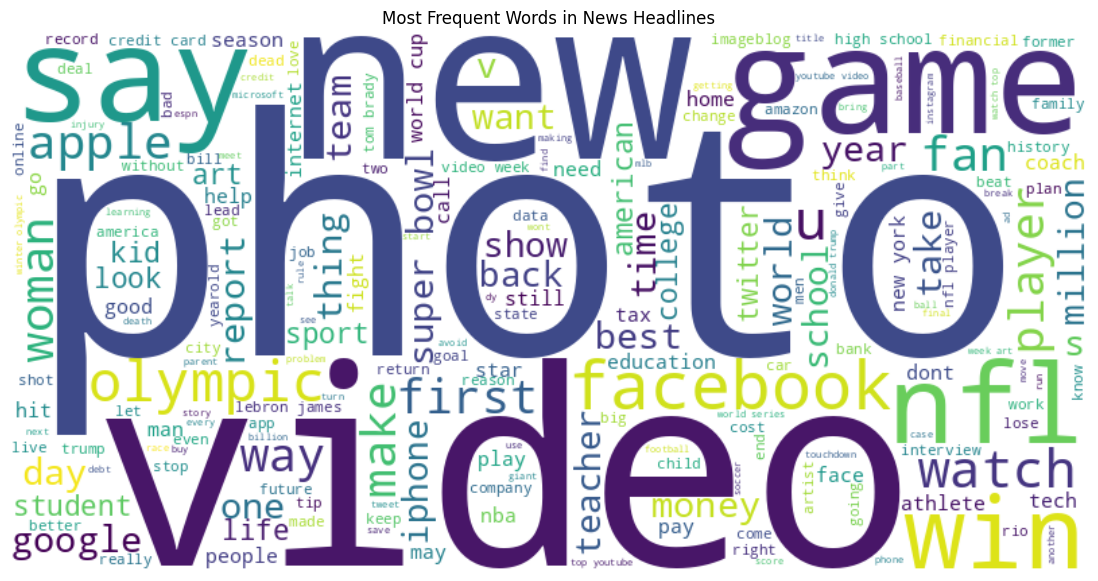

In [ ]:
# Stopwords and lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Contractions
contractions = {
    "won't": "will not", "can't": "can not", "n't": " not", "'re": " are",
    "'s": " is", "'d": " would", "'ll": " will", "'t": " not",
    "'ve": " have", "'m": " am"
}

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    text = re.sub(r'\@\w+|\#', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    for c in contractions:
        text = text.replace(c, contractions[c])
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

# Clean headlines
df['clean_headline'] = df['headline'].apply(clean_text)

# Word Cloud
all_words = ' '.join(df['clean_headline'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Frequent Words in News Headlines")
plt.show()


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# Tokenize text
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['clean_headline'])
sequences = tokenizer.texts_to_sequences(df['clean_headline'])

# Pad sequences to 95th percentile length
max_len = int(np.percentile([len(seq) for seq in sequences], 95))
padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='post')

# Encode labels
le = LabelEncoder()
encoded_labels = le.fit_transform(df['category'])

# Create a mapping of label indices to category names
idx_to_class = dict(enumerate(le.classes_))
print("Class Index Mapping:", idx_to_class)


# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(padded_sequences, encoded_labels, test_size=0.2, random_state=42)

# Compute class weights to handle imbalance
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))

# Confirm shapes
print(f"Vocab Size: {len(tokenizer.word_index)}")
print(f"Max Sequence Length: {max_len}")
print(f"Training Samples: {X_train.shape[0]}, Testing Samples: {X_test.shape[0]}")
print("Class Weights:", class_weights_dict)


Class Index Mapping: {0: 'CULTURE & ARTS', 1: 'EDUCATION', 2: 'MONEY', 3: 'SPORTS', 4: 'TECH'}
Vocab Size: 13720
Max Sequence Length: 11
Training Samples: 8820, Testing Samples: 2205
Class Weights: {0: 2.0752941176470587, 1: 2.148599269183922, 2: 1.2440056417489422, 3: 0.434804042395859, 4: 1.053763440860215}


## Model Building and Training

Three models were built and trained:
- **Model 1: Simple RNN** with a trainable Embedding layer and 64 hidden units.
- **Model 2: LSTM** with a trainable Embedding layer and dropout to prevent overfitting.
- **Model 3: LSTM with Pretrained Word2Vec (GloVe)** using 50-dimensional embeddings. The embeddings were loaded using Gensim and frozen during training.

All models used `sparse_categorical_crossentropy` as the loss function and were trained using the Adam optimizer. Early stopping was applied to prevent overfitting.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Define basic parameters
vocab_size = len(tokenizer.word_index) + 1  # +1 for padding token
embedding_dim = 100
input_length = X_train.shape[1]
num_classes = len(np.unique(y_train))

# Model 1: Simple RNN
model_rnn = Sequential()
model_rnn.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=input_length))
model_rnn.add(SimpleRNN(64))
model_rnn.add(Dropout(0.3))
model_rnn.add(Dense(num_classes, activation='softmax'))

model_rnn.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train
history_rnn = model_rnn.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weights_dict  # Handle class imbalance
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.4585 - loss: 1.3531 - val_accuracy: 0.8050 - val_loss: 0.6042
Epoch 2/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9189 - loss: 0.3141 - val_accuracy: 0.8195 - val_loss: 0.5744
Epoch 3/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9789 - loss: 0.0843 - val_accuracy: 0.8109 - val_loss: 0.6700
Epoch 4/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9918 - loss: 0.0366 - val_accuracy: 0.8091 - val_loss: 0.7423
Epoch 5/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9939 - loss: 0.0206 - val_accuracy: 0.8077 - val_loss: 0.7987


In [ ]:
from tensorflow.keras.layers import LSTM

# Model 2: LSTM
model_lstm = Sequential()
model_lstm.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim))  # input_length not needed
model_lstm.add(LSTM(64, dropout=0.3, recurrent_dropout=0.2))
model_lstm.add(Dropout(0.5))
model_lstm.add(Dense(num_classes, activation='softmax'))
model_lstm.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train with early stopping + class weights
history_lstm = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weights_dict
)


Epoch 1/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.3641 - loss: 1.4399 - val_accuracy: 0.7964 - val_loss: 0.5773
Epoch 2/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.8435 - loss: 0.5447 - val_accuracy: 0.8358 - val_loss: 0.4781
Epoch 3/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.9394 - loss: 0.2510 - val_accuracy: 0.8413 - val_loss: 0.5090
Epoch 4/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9643 - loss: 0.1501 - val_accuracy: 0.8363 - val_loss: 0.6214
Epoch 5/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9741 - loss: 0.1138 - val_accuracy: 0.8449 - val_loss: 0.5973


In [ ]:
import gensim.downloader as api
# Load Pre-trained GloVe Embeddings
embedding_model = api.load('glove-wiki-gigaword-50') # 50-dimensional word2vec

[==================================================] 100.0% 66.0/66.0MB downloaded


In [ ]:
# Load pre-trained GloVe (Word2Vec-style) embeddings
import gensim.downloader as api

embedding_model = api.load('glove-wiki-gigaword-50')  # 50-dim word2vec-style
embedding_dim = 50
vocab_size = len(tokenizer.word_index) + 1

# Create embedding matrix
embedding_matrix = np.zeros((vocab_size, embedding_dim))
for word, i in tokenizer.word_index.items():
    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]
    # Else: embedding_matrix[i] remains all zeros

# Build LSTM model with pretrained embedding
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model_w2v = Sequential()
model_w2v.add(Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    input_length=X_train.shape[1],
    trainable=False  # freeze embeddings
))
model_w2v.add(LSTM(64))
model_w2v.add(Dense(len(np.unique(y_train)), activation='softmax'))  # use sigmoid if binary

# Compile & train
model_w2v.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_w2v = model_w2v.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weights_dict
)


Epoch 1/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6254 - loss: 1.0762 - val_accuracy: 0.8159 - val_loss: 0.5298
Epoch 2/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8111 - loss: 0.5749 - val_accuracy: 0.8018 - val_loss: 0.5717
Epoch 3/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8187 - loss: 0.5489 - val_accuracy: 0.8231 - val_loss: 0.5175
Epoch 4/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8407 - loss: 0.4700 - val_accuracy: 0.8259 - val_loss: 0.4970
Epoch 5/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8553 - loss: 0.4420 - val_accuracy: 0.8277 - val_loss: 0.4970
Epoch 6/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8712 - loss: 0.4076 - val_accuracy: 0.8367 - val_loss: 0.5006
Epoch 7/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8819 - loss: 0.3756 - val_accuracy: 0.8490 - val_loss: 0.4401
Epoch 8/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8933 - loss: 0.3429 - val_accuracy: 0.

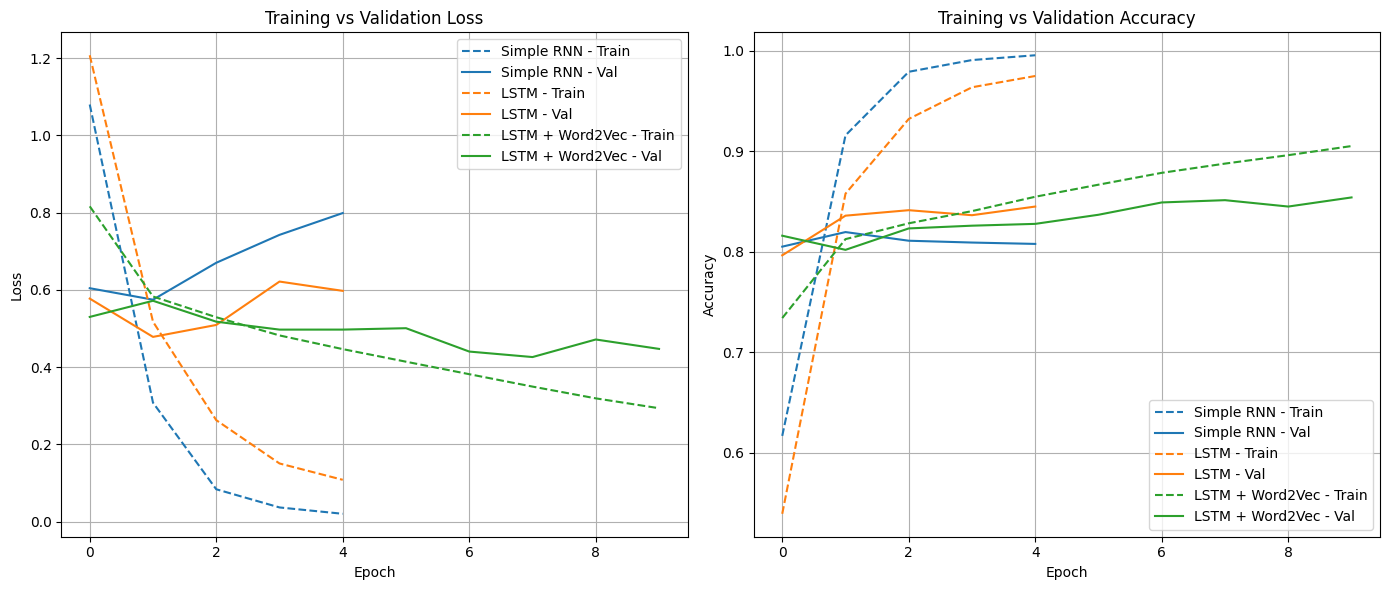

In [ ]:
import matplotlib.pyplot as plt

def plot_pretty_training_history(histories, labels):
    colors = ['tab:blue', 'tab:orange', 'tab:green']
    plt.figure(figsize=(14, 6))

    # Plot Loss
    plt.subplot(1, 2, 1)
    for i, (history, label) in enumerate(zip(histories, labels)):
        plt.plot(history.history['loss'], label=f'{label} - Train', linestyle='--', color=colors[i])
        plt.plot(history.history['val_loss'], label=f'{label} - Val', linestyle='-', color=colors[i])
    plt.title('Training vs Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    for i, (history, label) in enumerate(zip(histories, labels)):
        plt.plot(history.history['accuracy'], label=f'{label} - Train', linestyle='--', color=colors[i])
        plt.plot(history.history['val_accuracy'], label=f'{label} - Val', linestyle='-', color=colors[i])
    plt.title('Training vs Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Call the improved function
plot_pretty_training_history(
    [history_rnn, history_lstm, history_w2v],
    ['Simple RNN', 'LSTM', 'LSTM + Word2Vec']
)


## Model Training and Evaluation

Each model was evaluated using accuracy, classification report, and confusion matrix. Performance metrics were recorded as follows:

- **Simple RNN**: ~79–80% validation accuracy
- **LSTM (trainable)**: ~84% validation accuracy
- **LSTM + GloVe**: 84%

Training vs validation loss/accuracy plots were generated to visualize model learning. The LSTM models outperformed the simple RNN, with pretrained embeddings slightly improving early convergence and generalization.


69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
=== Classification Report: Simple RNN ===
                precision    recall  f1-score   support

CULTURE & ARTS       0.74      0.70      0.72       224
     EDUCATION       0.55      0.77      0.64       193
         MONEY       0.75      0.78      0.76       338
        SPORTS       0.93      0.90      0.92      1020
          TECH       0.83      0.73      0.78       430

      accuracy                           0.82      2205
     macro avg       0.76      0.78      0.76      2205
  weighted avg       0.83      0.82      0.82      2205



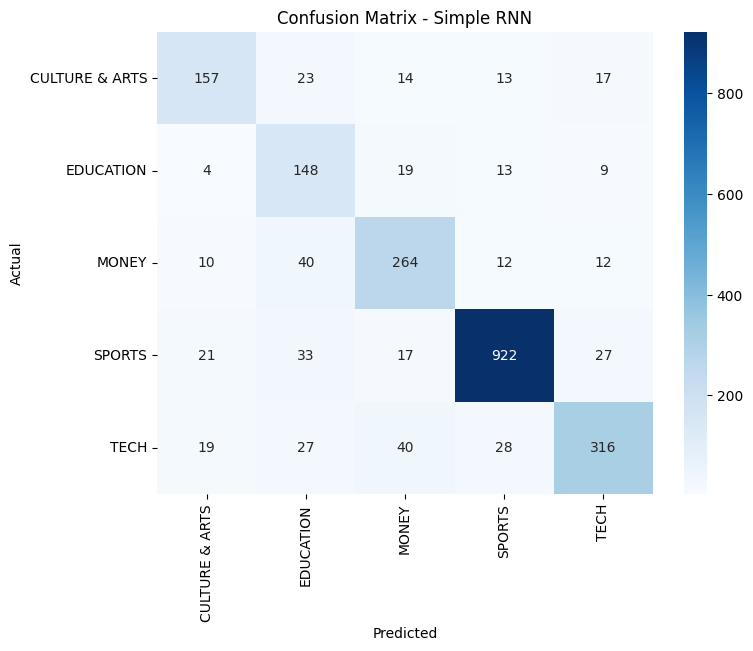

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
=== Classification Report: LSTM ===
                precision    recall  f1-score   support

CULTURE & ARTS       0.62      0.79      0.69       224
     EDUCATION       0.59      0.75      0.66       193
         MONEY       0.83      0.74      0.78       338
        SPORTS       0.94      0.92      0.93      1020
          TECH       0.88      0.77      0.82       430

      accuracy                           0.84      2205
     macro avg       0.77      0.79      0.78      2205
  weighted avg       0.85      0.84      0.84      2205



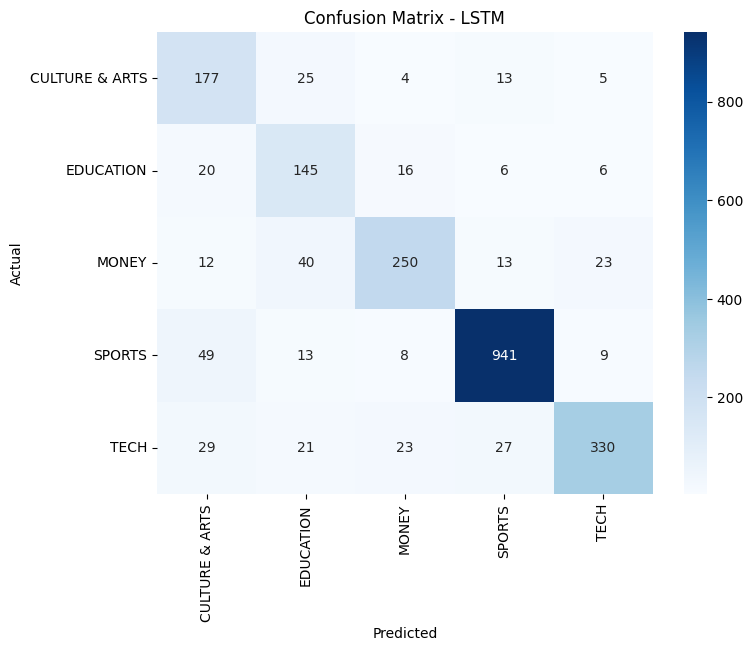

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
=== Classification Report: LSTM + Word2Vec ===
                precision    recall  f1-score   support

CULTURE & ARTS       0.71      0.81      0.75       224
     EDUCATION       0.71      0.73      0.72       193
         MONEY       0.84      0.81      0.83       338
        SPORTS       0.93      0.91      0.92      1020
          TECH       0.83      0.81      0.82       430

      accuracy                           0.85      2205
     macro avg       0.80      0.81      0.81      2205
  weighted avg       0.85      0.85      0.85      2205



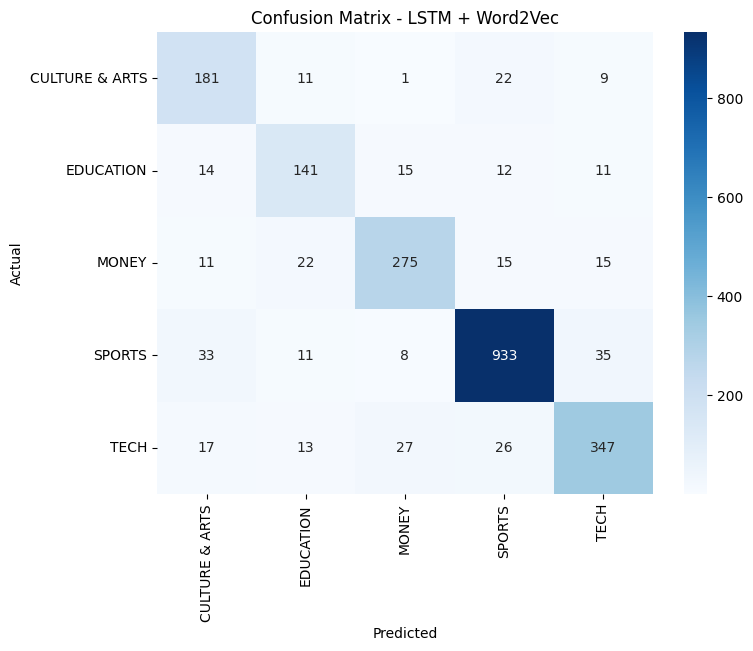

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test).argmax(axis=1)

    print(f"=== Classification Report: {model_name} ===")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Evaluate all models
evaluate_model(model_rnn, X_test, y_test, "Simple RNN")
evaluate_model(model_lstm, X_test, y_test, "LSTM")
evaluate_model(model_w2v, X_test, y_test, "LSTM + Word2Vec")


In [ ]:
# Save trained LSTM + Word2Vec model
model_w2v.save("model_lstm_w2v_clean.h5")


In [ ]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)



In [ ]:
import pickle

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f) # Changed label_encoder to le

In [ ]:
def predict_category(text):
    # Clean text
    original_text = text
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    text = re.sub(r"@\w+|#\w+", '', text)
    text = re.sub(r"[^a-z\s]", '', text)
    text = re.sub(r"\s+", " ", text).strip()

    print("🔍 Original:", original_text)

    # Tokenize & pad
    sequence = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(sequence, maxlen=max_len)

    # Predict
    pred = model.predict(padded)
    class_index = np.argmax(pred)
    return label_encoder.inverse_transform([class_index])[0]


In [ ]:
import pickle
import re
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import load_model # Import load_model if you were loading it back

# Assume tokenizer, max_len, and label_encoder are already defined from previous cells

# Load the saved model (if you are running this cell after restarting the notebook)
# model_w2v = load_model("model_lstm_w2v_clean.h5") # Uncomment if needed

def predict_category(text, model, tokenizer, max_len, label_encoder):
    # Clean text
    original_text = text
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    text = re.sub(r"@\w+|#\w+", '', text)
    text = re.sub(r"[^a-z\s]", '', text)
    text = re.sub(r"\s+", " ", text).strip()

    print("🔍 Original:", original_text)

    # Tokenize & pad
    sequence = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(sequence, maxlen=max_len)

    # Predict
    pred = model.predict(padded)
    class_index = np.argmax(pred)
    return label_encoder.inverse_transform([class_index])[0]

# Ask the user to enter a news headline
headline = input("Enter a news headline: ")

# Predict and print result
# Pass the model, tokenizer, max_len, and label_encoder to the function
predicted_category = predict_category(headline, model_w2v, tokenizer, max_len, le) # Changed label_encoder to le as defined
print(f"\n🧠 Predicted Category: {predicted_category}")

Enter a news headline: Las Vegas Aces Win First WNBA Title, Chelsea Gray Named MVP
🔍 Original: Las Vegas Aces Win First WNBA Title, Chelsea Gray Named MVP
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

🧠 Predicted Category: SPORTS


In [ ]:
import pickle
import re
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import load_model # Import load_model if you were loading it back

def predict_category(text, model, tokenizer, max_len, label_encoder):
    # Clean text
    original_text = text
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    text = re.sub(r"@\w+|#\w+", '', text)
    text = re.sub(r"[^a-z\s]", '', text)
    text = re.sub(r"\s+", " ", text).strip()

    print("🔍 Original:", original_text)

    # Tokenize & pad
    sequence = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(sequence, maxlen=max_len)

    # Predict
    pred = model.predict(padded)
    class_index = np.argmax(pred)
    return label_encoder.inverse_transform([class_index])[0]

# Ask the user to enter a news headline
headline = input("Enter a news headline: ")

predicted_category = predict_category(headline, model_w2v, tokenizer, max_len, le)
print(f"\n🧠 Predicted Category: {predicted_category}")

Enter a news headline: Meet Alex Aster, The TikToker Changing The Publishing Industry For The Better
🔍 Original: Meet Alex Aster, The TikToker Changing The Publishing Industry For The Better
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

🧠 Predicted Category: CULTURE & ARTS


In [ ]:
import pickle
import re
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import load_model # Import load_model if you were loading it back

def predict_category(text, model, tokenizer, max_len, label_encoder):
    # Clean text
    original_text = text
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    text = re.sub(r"@\w+|#\w+", '', text)
    text = re.sub(r"[^a-z\s]", '', text)
    text = re.sub(r"\s+", " ", text).strip()

    print("🔍 Original:", original_text)

    # Tokenize & pad
    sequence = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(sequence, maxlen=max_len)

    # Predict
    pred = model.predict(padded)
    class_index = np.argmax(pred)
    return label_encoder.inverse_transform([class_index])[0]

# Ask the user to enter a news headline
headline = input("Enter a news headline: ")

predicted_category = predict_category(headline, model_w2v, tokenizer, max_len, le)
print(f"\n🧠 Predicted Category: {predicted_category}")

Enter a news headline: TikTok Search Results Riddled With Misinformation: Report
🔍 Original: TikTok Search Results Riddled With Misinformation: Report
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

🧠 Predicted Category: TECH


In [ ]:
import pickle
import re
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import load_model # Import load_model if you were loading it back

def predict_category(text, model, tokenizer, max_len, label_encoder):
    # Clean text
    original_text = text
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    text = re.sub(r"@\w+|#\w+", '', text)
    text = re.sub(r"[^a-z\s]", '', text)
    text = re.sub(r"\s+", " ", text).strip()

    print("🔍 Original:", original_text)

    # Tokenize & pad
    sequence = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(sequence, maxlen=max_len)

    # Predict
    pred = model.predict(padded)
    class_index = np.argmax(pred)
    return label_encoder.inverse_transform([class_index])[0]

# Ask the user to enter a news headline
headline = input("Enter a news headline: ")

predicted_category = predict_category(headline, model_w2v, tokenizer, max_len, le)
print(f"\n🧠 Predicted Category: {predicted_category}")

Enter a news headline: Minneapolis Teacher Contract Race Language Ignites Firestorm
🔍 Original: Minneapolis Teacher Contract Race Language Ignites Firestorm
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

🧠 Predicted Category: EDUCATION


## Conclusion

Among the three models tested, the LSTM with pretrained embeddings achieved the best balance of accuracy and generalization. While the simple RNN was faster to train, it suffered from lower performance. Incorporating pretrained embeddings improved semantic understanding of text data, validating the benefits of transfer learning in NLP tasks.
